## Sprint 5: Graph RAG — The Adjacency Matrix

Vector RAG finds similar documents. Graph RAG finds connected documents.
We represent relationships as an adjacency matrix and use matrix 
multiplication to 
>
traverse the graph — finding neighbours of neighbours
in one operation.

**Building the Knowledge Graph**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Our 4 nodes - each represents a document in a medical base

nodes = {
    0: "Drug",
    1: "Ezyme",
    2: "Pathway",
    3: "Symptom"
}

# Edges - explicit relatioships between documents
# (0,1) means Drug s connected to Enzyme
# These would come from metadata, citations, or an entity extractio model

edges = [
    (0, 1), # Drug -> Enzyme
    (0, 2), # Drug -> Pathway
    (1, 3), # Enzyme -> Symptom
    (2, 3)  # Pathway -> Symptom
]

# Build the adjacency matrix from scratch
n_nodes = len(nodes)
A = np.zeros((n_nodes, n_nodes), dtype=int)

for i, j in edges:
    A[i, j] = 1   # i connects to j
    A[j, i] = 1   # j connects to i (undirected graph — road goes both ways)


print("Adjacency Matrix A:")
print(A)
print()
print("Reading the matrix:")
print(f"  A[0,1] = {A[0,1]} → Drug is connected to Enzyme")
print(f"  A[0,3] = {A[0,3]} → Drug is NOT directly connected to Symptom")

Adjacency Matrix A:
[[0 1 1 0]
 [1 0 0 1]
 [1 0 0 1]
 [0 1 1 0]]

Reading the matrix:
  A[0,1] = 1 → Drug is connected to Enzyme
  A[0,3] = 0 → Drug is NOT directly connected to Symptom


**Visualizing the Graph**

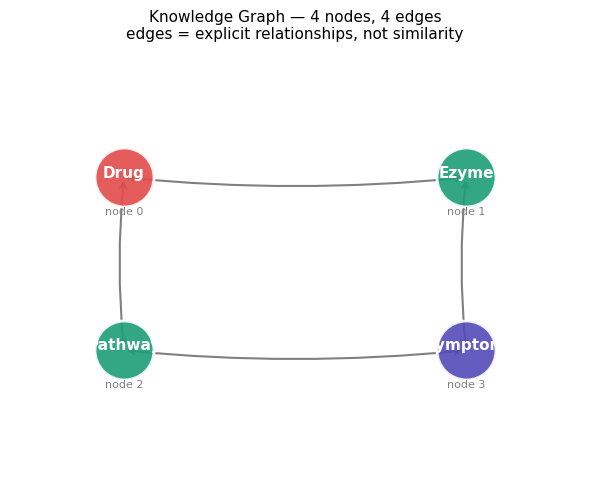

In [2]:
# Manual node positions for a clean layout
positions = {
    0: np.array([0.2, 0.7]),   # Drug       top-left
    1: np.array([0.8, 0.7]),   # Enzyme     top-right
    2: np.array([0.2, 0.3]),   # Pathway    bottom-left
    3: np.array([0.8, 0.3]),   # Symptom    bottom-right
}

colors = ["#E24B4A", "#1D9E75", "#1D9E75", "#534AB7"]

fig, ax = plt.subplots(figsize=(6, 5))

# Draw edges
for i, j in edges:
    p1, p2 = positions[i], positions[j]
    ax.annotate("",
                xy=p2, xytext=p1,
                arrowprops=dict(arrowstyle="<->", color="gray",
                                lw=1.5, connectionstyle="arc3,rad=0.05"))

# Draw nodes
for node_id, pos in positions.items():
    ax.scatter(*pos, s=1800, color=colors[node_id],
               zorder=3, alpha=0.9, edgecolors="white", linewidths=2)
    ax.text(pos[0], pos[1] + 0.01, nodes[node_id],
            ha="center", va="center", fontsize=11,
            fontweight="bold", color="white", zorder=4)
    ax.text(pos[0], pos[1] - 0.08, f"node {node_id}",
            ha="center", va="center", fontsize=8,
            color="gray")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("Knowledge Graph — 4 nodes, 4 edges\n"
             "edges = explicit relationships, not similarity",
             fontsize=11)
plt.tight_layout()
plt.savefig("../images/knowledge_graph.png", dpi=150, bbox_inches="tight")
plt.show()

**One-hop Traversal using Matrix Application**

A² = A @ A


A²[i,j] = number of distinct 2-hop paths from node i to node j

Why does this work?

Matrix multiplication computes: A²[i,j] = sum over k of A[i,k] * A[k,j]

That sum counts every node k that is both:
- a neighbour of i (A[i,k] = 1)
- a neighbour of j (A[k,j] = 1)
Each such k is a valid 2-hop path: i → k → j

In [3]:
A_squared = A @ A # pure NumPy matrix multiplication

print("A² (two-hop connection counts):")
print(A_squared)
print()

# Interpret the results for node 0 (Drug)
query_node = 0
two_hop_row = A_squared[query_node]

print(f"Starting from node {query_node} ({nodes[query_node]}):")
print(f"A²[{query_node}] = {two_hop_row}")
print()

for j, count in enumerate(two_hop_row):
    if j == query_node:
        continue
    if count > 0:
        print(f"  → {nodes[j]} (node {j}): reachable via {count} two-hop path(s)")
    else:
        print(f"  → {nodes[j]} (node {j}): not reachable in 2 hops")

A² (two-hop connection counts):
[[2 0 0 2]
 [0 2 2 0]
 [0 2 2 0]
 [2 0 0 2]]

Starting from node 0 (Drug):
A²[0] = [2 0 0 2]

  → Ezyme (node 1): not reachable in 2 hops
  → Pathway (node 2): not reachable in 2 hops
  → Symptom (node 3): reachable via 2 two-hop path(s)


**Full Graph Traversal Function**

Find all nodes reachable from query_node within a given number of hops.

Uses matrix exponentiation — A^n[i,j] > 0 means node j is reachable from node i in exactly n hops.

Args:
- query_node: the starting node index
- A:          adjacency matrix (n x n)
- nodes:      dict mapping node index to label
- hops:       how many hops to traverse

Returns:
- reachable: dict of {node_index: hop_distance}

In [4]:
def graph_traverse(query_node, A, nodes, hops=1):

    n = A.shape[0]
    reachable = {}

    # Walk through each hop level
    A_power = np.eye(n, dtype=int)

    for hop in range(1, hops + 1):
        A_power = A_power @ A

        for j in range(n):
            if j == query_node:
                continue
            if A_power[query_node, j] > 0 and j not in reachable:
                reachable[j] = hop
    
    return reachable

# Test: starting from Drug (node 0), traverse 1 hop
print("=== 1-Hop Traversal from Drug (node 0) ===")
result_1hop = graph_traverse(0, A, nodes, hops=1)
for node_id, distance in result_1hop.items():
    print(f"  {nodes[node_id]} (node {node_id}) — reachable in {distance} hop(s)")

print()

# Test: starting from Drug (node 0), traverse 2 hops
print("=== 2-Hop Traversal from Drug (node 0) ===")
result_2hop = graph_traverse(0, A, nodes, hops=2)
for node_id, distance in result_2hop.items():
    print(f"  {nodes[node_id]} (node {node_id}) — reachable in {distance} hop(s)")

=== 1-Hop Traversal from Drug (node 0) ===
  Ezyme (node 1) — reachable in 1 hop(s)
  Pathway (node 2) — reachable in 1 hop(s)

=== 2-Hop Traversal from Drug (node 0) ===
  Ezyme (node 1) — reachable in 1 hop(s)
  Pathway (node 2) — reachable in 1 hop(s)
  Symptom (node 3) — reachable in 2 hop(s)


**Combining Graph RAG & Vector Rag**

Hybrid retrieval: combine graph traversal with similarity scores.

- Step 1 — Graph: find all nodes reachable within 2 hops
- Step 2 — Vector: rank those nodes by similarity to query node
- Step 3 — Return top_k ranked by similarity, filtered by graph reachability

This is the core idea behind Microsoft's GraphRAG:
- use graph structure to FILTER candidates,
- use vector similarity to RANK them.

Args:
- query_node:        starting node
- A:                 adjacency matrix
- nodes:             node label dict
- similarity_matrix: cosine similarity between all node embeddings
- top_k:             how many results to return


In [5]:
def hybrid_retrieve(query_node, A, nodes, similarity_matrix, top_k=2):

    # Step 1 - get graph neighbors between 2 hops
    reachable = graph_traverse(query_node, A, nodes, hops=2)

    print(f"Graph found {len(reachable)} reachable nodes within 2 hops")

    # Step 2 — rank by similarity to query node
    candidates = []
    for node_id, hop_distance in reachable.items():
        sim_score = similarity_matrix[query_node, node_id]
        candidates.append((node_id, hop_distance, sim_score))

    # Sort by similarity descending
    candidates.sort(key=lambda x: x[2], reverse=True)

    print(f"\nHybrid results for '{nodes[query_node]}':")
    print(f"{'Node':<12} {'Hops':<8} {'Similarity':<12} {'Label'}")
    print("─" * 44)
    for node_id, hops, sim in candidates[:top_k]:
        print(f"{node_id:<12} {hops:<8} {sim:<12.4f} {nodes[node_id]}")

    return candidates[:top_k]


# Build a simple similarity matrix for our 4 nodes
# In production this would be cosine similarity between real embeddings
# Here we construct one manually to show the concept
similarity_matrix = np.array([
    [1.00, 0.82, 0.75, 0.31],   # Drug     similarities
    [0.82, 1.00, 0.60, 0.70],   # Enzyme   similarities
    [0.75, 0.60, 1.00, 0.68],   # Pathway  similarities
    [0.31, 0.70, 0.68, 1.00],   # Symptom  similarities
])

print("=== Hybrid Graph + Vector Retrieval ===\n")
results = hybrid_retrieve(0, A, nodes, similarity_matrix, top_k=2)

=== Hybrid Graph + Vector Retrieval ===

Graph found 3 reachable nodes within 2 hops

Hybrid results for 'Drug':
Node         Hops     Similarity   Label
────────────────────────────────────────────
1            1        0.8200       Ezyme
2            1        0.7500       Pathway


## Sprint 5: Graph RAG — The Adjacency Matrix

### The Core Shift
Vector RAG measures similarity — how close are two vectors?
Graph RAG traverses relationships — how are documents connected?

These answer different questions. A drug and a symptom may have
low cosine similarity but be deeply connected through a chain:
Drug → Enzyme → Pathway → Symptom.

---

### The Graph
A graph has two components:
- **Nodes** — documents in your knowledge base
- **Edges** — explicit relationships between them

The **adjacency matrix** A encodes the graph as math:

$$A_{ij} = \begin{cases} 1 & \text{if node } i
\text{ connects to node } j \\ 0 & \text{otherwise} \end{cases}$$

---

### Hops and Matrix Multiplication
A **hop** is one step along a connection.
Multiplying the adjacency matrix by itself reveals multi-hop paths:

$$A^2[i,j] = \sum_k A[i,k] \cdot A[k,j]$$

$A^2[i,j] > 0$ means node $j$ is reachable from node $i$ in 2 hops,
even if $A[i,j] = 0$ (no direct connection).

One matrix multiplication finds every 2-hop connection in the
entire graph simultaneously.

---

### Hybrid Retrieval
The most powerful retrieval combines both approaches:
- Step 1 — Graph:  find all nodes reachable within N hops  (structure)
- Step 2 — Vector: rank those nodes by cosine similarity   (relevance)
- Step 3 — Return: top-K candidates that are both connected AND relevant

Graph filters the candidate pool.
Vector ranks within that pool.
Together they recover reasoning chains that neither finds alone.

---

### What This Maps to in Production
| This notebook | Production system |
|---|---|
| Adjacency matrix | Neo4j, Amazon Neptune graph DB |
| `graph_traverse()` | Cypher / Gremlin graph queries |
| `hybrid_retrieve()` | Microsoft GraphRAG pipeline |
| Manual edges | Entity extraction + relation detection models |

